# Emotion classification from text (BiLSTM)



## 1. Setup

In [1]:
# Import libraries
import os
import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    f1_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:
# Load dataset
raw = load_dataset("mteb/emotion")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/128k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15956 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1988 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1986 [00:00<?, ? examples/s]

## 2. EDA


Columns: ['text', 'label', 'label_text']

Rows — train: 15956 | val: 1988 | test: 1986

First rows (train):


,text,label,label_text
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger


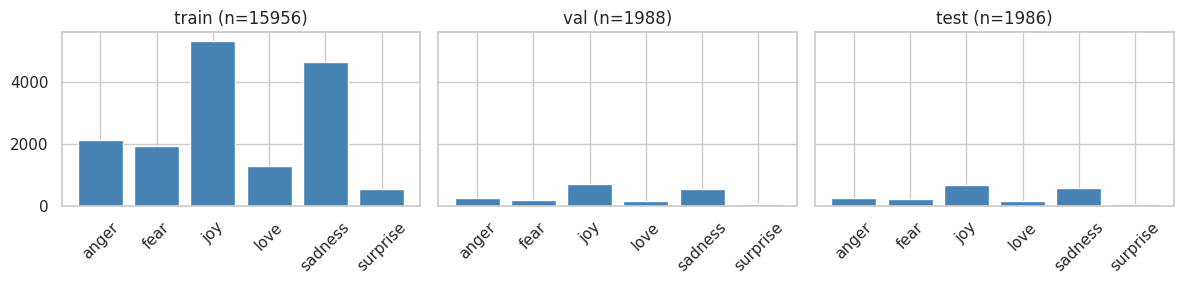


Random samples per class (train):

--- label=0 (sadness) ---
i sort of feel like one of those people who was unfortunate and lost their father when they were and life goes on
i wanted to write and feel purged of those repressed feelings
i have a neutral feeling about two broke girls because while i like kat denningss deadpan delivery and a href http media

--- label=1 (joy) ---
i cant help but feel as though perhaps my perception isnt as keen as i once thought
i feel honored to have that kind of support
i feel the determined nudge of the holy spirit to end my slumber and self love

--- label=2 (love) ---
i was like that i always wanted to feel and be accepted by my family and others
i feel a bit more loving energy inside connecting with you
i feel im being generous with that statement

--- label=3 (anger) ---
i was feeling frustrated at work wondering if i am living a life with meaning and purpose
i must say that the initial splash was not too bad but after a few strokes you could fee

In [3]:
# EDA
def hf_to_df(split_name):
    d = raw[split_name]
    return pd.DataFrame({"text": d["text"], "label": d["label"], "label_text": d["label_text"]})

train_df = hf_to_df("train")
val_df = hf_to_df("validation")
test_df = hf_to_df("test")

print("Columns:", list(train_df.columns))
print("\nRows — train:", len(train_df), "| val:", len(val_df), "| test:", len(test_df))
print("\nFirst rows (train):")
display(train_df.head(3))


# Class distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, (name, df) in zip(axes, [("train", train_df), ("val", val_df), ("test", test_df)]):
    vc = df["label_text"].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color="steelblue")
    ax.set_title(f"{name} (n={len(df)})")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


# Sample examples per class
print("\nRandom samples per class (train):")
for lab in sorted(train_df["label"].unique()):
    sub = train_df[train_df["label"] == lab]
    s = sub.sample(n=min(3, len(sub)), random_state=SEED)
    print(f"\n--- label={lab} ({s['label_text'].iloc[0]}) ---")
    for _, r in s.iterrows():
        print(r["text"][:200])


##3. Text preprocessing

In [4]:
def preprocess(text: str, lowercase: bool = True) -> str:
    t = str(text).strip()
    if lowercase:
        t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

# Preview
ex = train_df["text"].iloc[10]
print("Before:", ex)
print("After :", preprocess(ex))

Before: i feel like i have to make the suffering i m seeing mean something
After : i feel like i have to make the suffering i m seeing mean something


## 4. Label preparation

In [5]:
labels_sorted = sorted(train_df["label"].unique())
assert labels_sorted == list(range(len(labels_sorted))), "Labels should be 0..K-1"
num_classes = len(labels_sorted)
id2label = train_df.drop_duplicates("label").set_index("label")["label_text"].to_dict()
label2id = {v: k for k, v in id2label.items()}
print("num_classes:", num_classes)
print("id2label:", id2label)

num_classes: 6
id2label: {0: 'sadness', 3: 'anger', 2: 'love', 5: 'surprise', 4: 'fear', 1: 'joy'}


## 5. Split dataset


In [8]:
train_df["text_proc"] = train_df["text"].map(preprocess)
val_df["text_proc"] = val_df["text"].map(preprocess)
test_df["text_proc"] = test_df["text"].map(preprocess)

print("Split sizes:", len(train_df), len(val_df), len(test_df))

Split sizes: 15956 1988 1986


## 6. Vocabulary & sequences

In [9]:
# Special tokens
PAD, UNK = "<pad>", "<unk>"

# Only keep words that appear at least 2 times in the training set
min_freq = 2

def build_vocab(texts, min_freq=min_freq):
    """
    Build a word-to-id vocabulary from training texts only.

    Args:
        texts: iterable of processed text strings
        min_freq: minimum number of times a word must appear to be included in the vocabulary

    Returns:
        vocab: dict mapping token -> integer id
    """
    cnt = Counter()
    for t in texts:
        cnt.update(t.split())
    vocab = {PAD: 0, UNK: 1}
    for w, c in cnt.items():
        if c >= min_freq:
            vocab[w] = len(vocab)
    return vocab

def texts_to_ids(texts, vocab, max_len):
    """
    Convert text strings into fixed-length sequences of token ids. Steps:
    1. Split each text into words
    2. Convert each word to its id using vocab - if word not found, use <unk> id
    3. Truncate sequence to max_len if too long
    4. Pad sequence with <pad> id if too short

    Args:
        texts: iterable of processed text strings
        vocab: token -> id dictionary
        max_len: fixed sequence length for all samples

    Returns:
        np.array of shape (num_samples, max_len)
    """
    pad_id, unk_id = vocab[PAD], vocab[UNK]
    rows = []
    for t in texts:
        ids = [vocab.get(w, unk_id) for w in t.split()][:max_len]
        pad_len = max_len - len(ids)
        ids = ids + [pad_id] * pad_len
        rows.append(ids)
    return np.array(rows, dtype=np.int64)

# Choose max_len from train word-length percentiles (~95% coverage)
_wc = train_df["text_proc"].map(lambda s: len(s.split()))
max_len = int(np.clip(_wc.quantile(0.95), 16, 128))
print("Chosen max_len (95p train word count, clipped 16–128):", max_len)

# Build vocab only on the training set to avoid data leakage
vocab = build_vocab(train_df["text_proc"], min_freq=min_freq)
vocab_size = len(vocab)
print("vocab_size:", vocab_size)

# Convert text data into padded token-id sequences
X_train = texts_to_ids(train_df["text_proc"], vocab, max_len)
X_val = texts_to_ids(val_df["text_proc"], vocab, max_len)
X_test = texts_to_ids(test_df["text_proc"], vocab, max_len)
y_train = train_df["label"].to_numpy()
y_val = val_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)


Chosen max_len (95p train word count, clipped 16–128): 41
vocab_size: 7386
Shapes: (15956, 41) (1988, 41) (1986, 41)


In [10]:
sample_text = train_df["text_proc"].iloc[69]
sample_ids = texts_to_ids([sample_text], vocab, max_len)[0]

print("Original text:")
print(sample_text)

print("\nWords:")
print(sample_text.split())

print("\nToken IDs:")
print(sample_ids)

print("\nLength after padding/truncation:")
print(len(sample_ids))

Original text:
i was feeling brave when i bought it and clearly when i was doing my makeup

Words:
['i', 'was', 'feeling', 'brave', 'when', 'i', 'bought', 'it', 'and', 'clearly', 'when', 'i', 'was', 'doing', 'my', 'makeup']

Token IDs:
[  2  53   9 358 229   2 544  40  21 545 229   2  53 164 174 546   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0]

Length after padding/truncation:
41


## 7. PyTorch Dataset / DataLoader

In [11]:
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def make_loader(X, y, batch_size, shuffle):
    ds = EmotionDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 64
train_loader = make_loader(X_train, y_train, BATCH_SIZE, True)
val_loader = make_loader(X_val, y_val, BATCH_SIZE, False)
test_loader = make_loader(X_test, y_test, BATCH_SIZE, False)


## 8. Transformer model

In [12]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128, mode='sinusoidal'):
        super().__init__()
        self.mode = mode
        if mode == 'sinusoidal':
            pe = torch.zeros(max_len, d_model)
            position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
            div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(position * div_term)
            pe[:, 1::2] = torch.cos(position * div_term)
            self.register_buffer('pe', pe.unsqueeze(0))
        else:
            self.pe = nn.Parameter(torch.randn(1, max_len, d_model))

    def forward(self, x):
        if self.mode == 'sinusoidal':
            return x + self.pe[:, :x.size(1)]
        return x + self.pe[:, :x.size(1)]

class TransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        ff_dim,
        num_layers,
        num_classes,
        max_len,
        dropout=0.1,
        attn_dropout=0.1,
        norm_position='post',
        activation='relu',
        pos_encoding='sinusoidal',
        mlp_hidden=None,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab[PAD])
        self.pos_encoding = PositionalEncoding(embed_dim, max_len, mode=pos_encoding)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation=activation,
            batch_first=True,
            norm_first=(norm_position == 'pre')
        )
        # Note: PyTorch's TransformerEncoderLayer has dropout for attention internally
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        mlp_layers = []
        in_dim = embed_dim
        if mlp_hidden is not None:
            for h in mlp_hidden:
                mlp_layers.append(nn.Linear(in_dim, h))
                mlp_layers.append(nn.ReLU())
                mlp_layers.append(nn.Dropout(dropout))
                in_dim = h
        mlp_layers.append(nn.Linear(in_dim, num_classes))
        self.classifier = nn.Sequential(*mlp_layers)

    def forward(self, x):
        padding_mask = (x == vocab[PAD])
        x = self.embedding(x)
        x = self.pos_encoding(x)
        x = self.transformer(x, src_key_padding_mask=padding_mask)

        # Global Average Pooling
        mask = (~padding_mask).unsqueeze(-1).float()
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        return self.classifier(pooled)

In [ ]:
import torch
import optuna
from optuna.samplers import TPESampler

def tune_transformer_complex_bayes(n_trials=30, timeout=None):
    def objective(trial):
        # 1. ENHANCED ARCHITECTURE GEOMETRY
        # We ensure embed_dim is always divisible by num_heads
        num_heads = trial.suggest_categorical("num_heads", [4, 8, 12, 16])
        head_dim = trial.suggest_categorical("head_dim", [16, 32, 64])
        embed_dim = num_heads * head_dim

        ff_mult = trial.suggest_float("ff_mult", 2.0, 4.0)
        ff_dim = int(embed_dim * ff_mult)

        num_layers = trial.suggest_int("num_layers", 3, 8)

        # 2. STRUCTURAL CONFIGURATIONS
        norm_position = trial.suggest_categorical("norm_position", ["pre", "post"])
        activation = trial.suggest_categorical("activation", ["relu", "gelu"])
        pos_encoding = trial.suggest_categorical("pos_encoding", ["sinusoidal", "learned"])

        # 3. ADVANCED DROPOUT STRATEGY
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        attn_dropout = trial.suggest_float("attn_dropout", 0.0, 0.2)

        # 4. DEEPER MLP HEAD
        # Suggesting number of hidden layers in the classifier head
        mlp_depth = trial.suggest_int("mlp_depth", 1, 3)
        mlp_hidden_base = trial.suggest_categorical("mlp_hidden_base", [256, 512])
        # Construct list: [512, 256] etc based on depth
        mlp_hidden = [mlp_hidden_base // (2**i) for i in range(mlp_depth)]

        # 5. OPTIMIZATION HYPERPARAMETERS
        lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        # Add a warmup period for the transformer stability
        warmup_steps = trial.suggest_int("warmup_steps", 0, 500)

        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

        # Model initialization with new complex params
        # Note: Your TransformerClassifier class needs to support these new args
        model = TransformerClassifier(
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            num_layers=num_layers,
            num_classes=num_classes,
            max_len=max_len,
            dropout=dropout,
            attn_dropout=attn_dropout, # Added
            norm_position=norm_position, # Added
            activation=activation, # Added
            pos_encoding=pos_encoding, # Added
            mlp_hidden=mlp_hidden,
        ).to(device)

        # Standard training boilerplate
        trial_train_loader = make_loader(X_train, y_train, batch_size, True)
        trial_val_loader = make_loader(X_val, y_val, batch_size, False)

        try:
            # Modified train_model to accept warmup_steps
            _, best_f1 = train_model(
                model,
                trial_train_loader,
                trial_val_loader,
                epochs=25,
                lr=lr,
                weight_decay=weight_decay,
                warmup_steps=warmup_steps,
                patience=4,
                trial=trial # Passing trial for pruning
            )
        except optuna.exceptions.TrialPruned:
            raise optuna.exceptions.TrialPruned()
        except Exception as e:
            print(f"Trial failed due to: {e}")
            return 0.0
        finally:
            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        return best_f1

    # TPE Sampler with Multivariate support (correlates hyperparameters)
    sampler = TPESampler(seed=SEED, multivariate=True)
    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        pruner=optuna.pruners.MedianPruner() # Stops poor trials early
    )

    study.optimize(objective, n_trials=n_trials, timeout=timeout)

    return study.best_params, study


## 8.1 Hyperparameter tuning (Bayesian)

In [ ]:
best_params, study = tune_transformer_complex_bayes(n_trials=100)

[I 2026-05-06 09:46:22,469] A new study created in memory with name: no-name-d0e7c305-7f17-49fa-b1aa-fd5589dc503e
[I 2026-05-06 09:47:39,068] Trial 0 finished with value: 0.862613771080364 and parameters: {'num_heads': 8, 'head_dim': 16, 'ff_mult': 3.73235229154987, 'num_layers': 6, 'norm_position': 'pre', 'activation': 'relu', 'pos_encoding': 'sinusoidal', 'dropout': 0.17336180394137352, 'attn_dropout': 0.06084844859190755, 'mlp_depth': 2, 'mlp_hidden_base': 256, 'lr': 0.00016738085788752134, 'weight_decay': 3.6138942712165278e-06, 'warmup_steps': 146, 'batch_size': 128}. Best is trial 0 with value: 0.862613771080364.
[I 2026-05-06 09:51:54,883] Trial 1 finished with value: 0.8628371959012227 and parameters: {'num_heads': 12, 'head_dim': 16, 'ff_mult': 3.8977710745066663, 'num_layers': 8, 'norm_position': 'pre', 'activation': 'gelu', 'pos_encoding': 'sinusoidal', 'dropout': 0.29807076404450805, 'attn_dropout': 0.006877704223043679, 'mlp_depth': 3, 'mlp_hidden_base': 512, 'lr': 4.20167

### 8.2 Review Tuning Results
After the tuning completes, we can visualize which hyperparameters were most important and confirm our final selection.

In [ ]:
import optuna.visualization as vis

print("Best Macro-F1 found:", study.best_value)
print("Best Parameters:", best_params)

# Visualize hyperparameter importance
try:
    display(vis.plot_optimization_history(study))
    display(vis.plot_param_importances(study))
except Exception as e:
    print(f"Could not plot: {e}")

In [13]:
# Train the model for one epoch
def train_one_epoch(model, loader, optimizer, criterion):
    # Set model to training mode
    # This enables dropout and other training-specific behavior
    model.train()
    total_loss = 0.0

    # Loop through batches from DataLoader
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)

        # Forward pass: compute predicted logits
        logits = model(xb)

        # Compute loss between prediction and true labels
        loss = criterion(logits, yb)

        # Backpropagation: compute gradients
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        # Useful for RNN/LSTM training stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update model parameters
        optimizer.step()

        # Accumulate total loss weighted by batch size
        total_loss += loss.item() * xb.size(0)

    # Return average loss over the whole dataset
    return total_loss / len(loader.dataset)


# Evaluate model on validation or test set
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    # Set model to evaluation mode - disables dropout
    model.eval()
    total_loss = 0.0
    all_y, all_p = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        # Forward pass
        logits = model(xb)

        # Compute loss only if criterion is provided
        if criterion is not None:
            total_loss += criterion(logits, yb).item() * xb.size(0)

        # Predicted class = index of highest logit
        all_p.append(logits.argmax(dim=-1).cpu().numpy())

        # Store true labels
        all_y.append(yb.cpu().numpy())

    # Merge all batches into full arrays
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)

    # Compute evaluation metrics
    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),

    }

    # Add average loss if criterion was used
    if criterion is not None:
        metrics["loss"] = total_loss / len(loader.dataset)

    return metrics, y_true, y_pred

## 9. Training - CrossEntropyLoss, Adam, early stopping on val macro-F1

In [14]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=1e-3,
    weight_decay=1e-5,
    warmup_steps=0,
    patience=3,
    trial=None
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Simple Linear Warmup
    scheduler = None
    if warmup_steps > 0:
        def lr_lambda(current_step: int):
            if current_step < warmup_steps:
                return float(current_step) / float(max(1, warmup_steps))
            return 1.0
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_acc": []}
    best_state = None
    best_f1 = -1.0
    stale = 0
    global_step = 0

    for ep in range(1, epochs + 1):
        model.train()
        total_tl = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            if scheduler: scheduler.step()
            total_tl += loss.item() * xb.size(0)
            global_step += 1

        vm, _, _ = evaluate(model, val_loader, criterion)
        history["train_loss"].append(total_tl / len(train_loader.dataset))
        history["val_loss"].append(vm["loss"])
        history["val_macro_f1"].append(vm["macro_f1"])
        history["val_acc"].append(vm["acc"])

        if vm["macro_f1"] > best_f1:
            best_f1 = vm["macro_f1"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1

        # Optuna Pruning
        if trial is not None:
            trial.report(vm["macro_f1"], ep)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        if stale >= patience: break

    if best_state is not None: model.load_state_dict(best_state)
    return history, best_f1

In [18]:
def plot_history(history, title="Training History"):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='tab:red')
    ax1.plot(history['train_loss'], label='Train Loss', color='tab:red', linestyle='--')
    ax1.plot(history['val_loss'], label='Val Loss', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Macro-F1 / Acc', color='tab:blue')
    ax2.plot(history['val_macro_f1'], label='Val Macro-F1', color='tab:blue')
    ax2.plot(history['val_acc'], label='Val Acc', color='tab:cyan')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title(title)
    fig.tight_layout()
    plt.show()

In [17]:
print("hello")

hello


## 10. Train Transformer


In [16]:
# Set random seed for reproducibility
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

default_params = {
    "embed_dim": 128,
    "num_heads": 4,
    "ff_dim": 384,
    "num_layers": 3,
    "dropout": 0.1,
    "mlp_hidden": [192],
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": 64,
    "epochs": 25,
    "patience": 3,
}

train_loader_default = make_loader(X_train, y_train, default_params["batch_size"], True)
val_loader_default = make_loader(X_val, y_val, default_params["batch_size"], False)

# Default Transformer (no tuning)
baseline_model = TransformerClassifier(
    vocab_size=vocab_size,
    embed_dim=default_params["embed_dim"],
    num_heads=default_params["num_heads"],
    ff_dim=default_params["ff_dim"],
    num_layers=default_params["num_layers"],
    num_classes=num_classes,
    max_len=max_len,
    dropout=default_params["dropout"],
    mlp_hidden=default_params["mlp_hidden"],
).to(device)

hist_default, best_val_f1_default = train_model(
    baseline_model,
    train_loader_default,
    val_loader_default,
    epochs=default_params["epochs"],
    lr=default_params["lr"],
    weight_decay=default_params["weight_decay"],
    patience=default_params["patience"],
)

print("Best val macro-F1 (default):", best_val_f1_default)
plot_history(
    hist_default,
    title=(
        f"Default Transformer (embed={default_params['embed_dim']}, "
        f"layers={default_params['num_layers']}, heads={default_params['num_heads']})"
    ),
)

KeyboardInterrupt: 

## 10.1 Train Transformer (tuned)

In [ ]:
if "best_params" not in globals() or best_params is None:
    raise ValueError("Run the tuning cell to create best_params before training the tuned model.")

params_tuned = {**default_params, **best_params}

train_loader = make_loader(X_train, y_train, params_tuned["batch_size"], True)
val_loader = make_loader(X_val, y_val, params_tuned["batch_size"], False)

# Tuned Transformer
main_model = TransformerClassifier(
    vocab_size=vocab_size,
    embed_dim=params_tuned["embed_dim"],
    num_heads=params_tuned["num_heads"],
    ff_dim=params_tuned["ff_dim"],
    num_layers=params_tuned["num_layers"],
    num_classes=num_classes,
    max_len=max_len,
    dropout=params_tuned["dropout"],
    mlp_hidden=params_tuned["mlp_hidden"],
).to(device)

hist_tuned, best_val_f1_tuned = train_model(
    main_model,
    train_loader,
    val_loader,
    epochs=params_tuned["epochs"],
    lr=params_tuned["lr"],
    weight_decay=params_tuned["weight_decay"],
    patience=params_tuned["patience"],
)

print("Best val macro-F1 (tuned):", best_val_f1_tuned)
plot_history(
    hist_tuned,
    title=(
        f"Tuned Transformer (embed={params_tuned['embed_dim']}, "
        f"layers={params_tuned['num_layers']}, heads={params_tuned['num_heads']})"
    ),
)

## 11. Evaluation

In [ ]:
def full_report(y_true, y_pred, split_name="val"):
    """
    Print a full classification report and plot the confusion matrix.

    Args:
        y_true: true labels
        y_pred: predicted labels
        split_name: name of the data split, e.g. 'validation' or 'test'

    Returns:
        cm: confusion matrix as a NumPy array
    """

    # Create class names in label-id order
    names = [id2label[i] for i in sorted(id2label.keys())]

    # Print split name
    print(f"=== {split_name} ===")

    # Print overall accuracy
    print("Accuracy:", accuracy_score(y_true, y_pred))

    # Compute per-class precision, recall, and F1
    # average=None means return metric for each class separately
    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        labels=sorted(id2label.keys())
    )

    # Print metrics for each class
    print("\nPer-class precision/recall/F1:")
    for i, lab in enumerate(sorted(id2label.keys())):
        print(f"  {names[i]:10s}  P={p[i]:.3f}  R={r[i]:.3f}  F1={f1[i]:.3f}")

    # Print macro-F1 and weighted-F1
    print(
        "\nMacro / weighted F1:",
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted")

    )

    # Print sklearn's detailed classification report
    print("\n", classification_report(y_true, y_pred, target_names=names, digits=3))

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=sorted(id2label.keys()))

    # Plot confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,         # show numbers inside cells
        fmt="d",            # integer format
        cmap="Blues",
        xticklabels=names,
        yticklabels=names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion matrix — {split_name}")
    plt.tight_layout()
    plt.show()

    return cm

# Evaluate both models on the validation set
_, yv_t_base, yv_p_base = evaluate(baseline_model, val_loader_default, nn.CrossEntropyLoss())
full_report(yv_t_base, yv_p_base, "Validation baseline")

_, yv_t_tuned, yv_p_tuned = evaluate(main_model, val_loader, nn.CrossEntropyLoss())
full_report(yv_t_tuned, yv_p_tuned, "Validation tuned")

## 12. Error analysis


In [ ]:
# Run evaluation on the validation set
_, yv_t, yv_p = evaluate(main_model, val_loader, None)

# Create ordered class names from label ids
names = [id2label[i] for i in sorted(id2label.keys())]

# Build confusion matrix
cm = confusion_matrix(yv_t, yv_p, labels=sorted(id2label.keys()))

# Find the most common confusion pairs
pairs = []
n = cm.shape[0]
for i in range(n):
    for j in range(n):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], names[i], names[j]))
pairs.sort(reverse=True)

# Print the most frequent confusion types
print("Top confused (true -> pred):")
for c, a, b in pairs[:8]:
    print(f"  {c:4d}  {a} -> {b}")

# Show some actual misclassified validation examples
val_texts = val_df["text_proc"].to_numpy()
wrong_idx = np.where(yv_t != yv_p)[0]
sample = np.random.default_rng(SEED).choice(wrong_idx, size=min(12, len(wrong_idx)), replace=False)
print("\nSample errors (val):")
for i in sample:
    print(f"\n true={names[yv_t[i]]} pred={names[yv_p[i]]}")
    print(" ", val_texts[i][:280])